### Predictive Asset Modeling — BOE Optimization

#### ML Engineering Track | Niger Delta Upstream Production Analysis
#### Fields: Bonga | Agbami | Forcados Yokri | Egina | Oben
#### Model Type: Random Forest Regressor + Isolation Forest Anomaly Detection + Hierarchical Clustering
#### Data Period: January 2023 – March 2025

This notebook covers the full ML engineering pipeline:
Feature Engineering (GOR, Water Cut, BOE, Lag Features, Rolling Averages), Predictive BOE Modeling (Random Forest Regressor), Model Evaluation (MAE, RMSE, R²), Anomaly/Failure Detection, (Isolation Forest), Well Segmentation (Hierarchical Clustering)

In [1]:
#Importing the needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### 1. Data Loading & Exploration

We load the upstream production dataset covering five Niger Delta fields. Each row represents one well's production record for a given month, containing oil, gas, and water volumes alongside operational metadata.

In [2]:
#Loading the dataset
data = pd.read_csv('upstream_oil_gas.csv')
data.head()

,productionid,productiondate,wellid,wellname,welltype,status,fieldname,basin,region,operator,year,quarter,monthnumber,monthname,oilvolumebbl,gasvolumemcf,watervolumebbl,realizedoilprice,operatingcostusd
0,100001,1/31/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q1,1,Jan,117234.0,285727,7483.0,80.25,493580
1,100002,2/28/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q1,2,Feb,108067.0,290675,8384.5,75.98,393738
2,100003,3/31/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q1,3,Mar,120808.0,337351,11078.5,73.96,245378
3,100004,4/30/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q2,4,Apr,104046.0,337306,11049.1,71.46,442843
4,100005,5/31/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q2,5,May,118250.0,417774,14317.3,73.59,474604


In [3]:
data.shape

(338, 19)

### 2. Feature Engineering

#### 2.1 Gas-Oil Ratio (GOR)

GOR measures how much gas is produced relative to oil. It is a key diagnostic indicator of reservoir pressure — a rising GOR over time signals declining pressure or gas cap expansion.

Formula: GOR = GasVolumeMCF ÷ OilVolumeBBL

In [4]:
#Creating the GOR column
data['GOR'] = data['gasvolumemcf'] / data['oilvolumebbl']
data.head()

,productionid,productiondate,wellid,wellname,welltype,status,fieldname,basin,region,operator,year,quarter,monthnumber,monthname,oilvolumebbl,gasvolumemcf,watervolumebbl,realizedoilprice,operatingcostusd,GOR
0,100001,1/31/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q1,1,Jan,117234.0,285727,7483.0,80.25,493580,2.437237
1,100002,2/28/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q1,2,Feb,108067.0,290675,8384.5,75.98,393738,2.689767
2,100003,3/31/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q1,3,Mar,120808.0,337351,11078.5,73.96,245378,2.792456
3,100004,4/30/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q2,4,Apr,104046.0,337306,11049.1,71.46,442843,3.241893
4,100005,5/31/2023,W001,BNG-07,Oil Producer,Producing,Bonga,Niger Delta,Offshore Deepwater,Crestmount E&P,2023,Q2,5,May,118250.0,417774,14317.3,73.59,474604,3.532973


In [5]:
data[['status']].value_counts()

status             
Producing              279
Shut-in                 41
Plugged & Abandoned     18
Name: count, dtype: int64

#### 2.2 Categorical Encoding

Three categorical columns — region, welltype, and operator — must be converted to numeric format before they can be used by the machine learning model. We first inspect the unique value counts in each column, then apply one-hot encoding using drop_first=True to avoid multicollinearity.

In [6]:
#Checking the selected columns to better understand them
data[['region', 'welltype', 'operator']].value_counts()

region              welltype      operator        
Offshore Deepwater  Oil Producer  Star Deep Energy    74
                                  Crestmount E&P      60
                                  Aurora Upstream     50
Onshore             Oil Producer  Seplat-like NPDC    50
                                  Delta Petroleum     48
Offshore Deepwater  Gas Producer  Crestmount E&P      29
                                  Aurora Upstream     27
Name: count, dtype: int64

In [7]:
data['operator'].value_counts()

operator
Crestmount E&P      89
Aurora Upstream     77
Star Deep Energy    74
Seplat-like NPDC    50
Delta Petroleum     48
Name: count, dtype: int64

In [8]:
data['region'].value_counts()

region
Offshore Deepwater    240
Onshore                98
Name: count, dtype: int64

In [9]:
data['welltype'].value_counts()


welltype
Oil Producer    282
Gas Producer     56
Name: count, dtype: int64

In [10]:
#Encoding my selected categorical columns
data = pd.get_dummies(data, columns=['region', 'welltype', 'operator'], drop_first=True, dtype=int)
data.head()

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,watervolumebbl,realizedoilprice,operatingcostusd,GOR,region_Onshore,welltype_Oil Producer,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy
0,100001,1/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,1,...,7483.0,80.25,493580,2.437237,0,1,1,0,0,0
1,100002,2/28/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,2,...,8384.5,75.98,393738,2.689767,0,1,1,0,0,0
2,100003,3/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,3,...,11078.5,73.96,245378,2.792456,0,1,1,0,0,0
3,100004,4/30/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q2,4,...,11049.1,71.46,442843,3.241893,0,1,1,0,0,0
4,100005,5/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q2,5,...,14317.3,73.59,474604,3.532973,0,1,1,0,0,0


### 2.3 Water Cut

Water Cut is the fraction of total liquid production that consists of water. It is one of the most important reservoir maturity indicators — as a well matures, water cut rises, which increases operating costs and signals the need for intervention.

Formula: Water Cut = WaterVolumeBBL ÷ (OilVolumeBBL + WaterVolumeBBL)

Result is expressed as a decimal between 0 and 1.

In [11]:
#.Creating the water cut column
data['watercut'] = data['watervolumebbl'] / (data['oilvolumebbl'] + data['watervolumebbl'])
data.head()

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,realizedoilprice,operatingcostusd,GOR,region_Onshore,welltype_Oil Producer,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut
0,100001,1/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,1,...,80.25,493580,2.437237,0,1,1,0,0,0,0.060
1,100002,2/28/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,2,...,75.98,393738,2.689767,0,1,1,0,0,0,0.072
2,100003,3/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,3,...,73.96,245378,2.792456,0,1,1,0,0,0,0.084
3,100004,4/30/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q2,4,...,71.46,442843,3.241893,0,1,1,0,0,0,0.096
4,100005,5/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q2,5,...,73.59,474604,3.532973,0,1,1,0,0,0,0.108


### 2.4 Rolling Average Water Cut

A 3-month rolling average of water cut smooths out month-to-month noise and gives the model a more stable trend signal. The data is first sorted by wellid and productiondate to ensure chronological order per well before the rolling window is applied.

In [12]:
#Sorting the values of well id and production date
data = data.sort_values(['wellid', 'productiondate'])


In [13]:
#Creating the rolling average column
data['watercut_rolling_avg'] = data.groupby('wellid')['watercut'].transform(
    lambda x: x.rolling(window=3).mean()
)
data.head()

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,operatingcostusd,GOR,region_Onshore,welltype_Oil Producer,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg
0,100001,1/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,1,...,493580,2.437237,0,1,1,0,0,0,0.060,NaN
12,100013,1/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q1,1,...,202504,2.851750,0,1,1,0,0,0,0.204,NaN
24,100025,1/31/2025,W001,BNG-07,Producing,Bonga,Niger Delta,2025,Q1,1,...,295660,3.402903,0,1,1,0,0,0,0.348,0.204
9,100010,10/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q4,10,...,494633,2.654926,0,1,1,0,0,0,0.168,0.240
21,100022,10/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q4,10,...,339137,3.143829,0,1,1,0,0,0,0.312,0.276


### 2.5 Barrels of Oil Equivalent (BOE)

BOE converts multi-phase production (oil + gas) into a single unified energy metric, enabling fair comparison across wells and fields regardless of their production mix.

Formula: BOE = OilVolumeBBL + (GasVolumeMCF ÷ 6)


The conversion factor of 6 reflects the energy equivalence: 6 MCF of natural gas contains roughly the same energy as 1 barrel of crude oil (standard industry factor).

In [14]:
#Creating the BOE column
data['BOE'] = data['oilvolumebbl'] + (data['gasvolumemcf'] / 6)
data.head()

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,GOR,region_Onshore,welltype_Oil Producer,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg,BOE
0,100001,1/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,1,...,2.437237,0,1,1,0,0,0,0.060,NaN,164855.166667
12,100013,1/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q1,1,...,2.851750,0,1,1,0,0,0,0.204,NaN,146822.500000
24,100025,1/31/2025,W001,BNG-07,Producing,Bonga,Niger Delta,2025,Q1,1,...,3.402903,0,1,1,0,0,0,0.348,0.204,124383.166667
9,100010,10/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q4,10,...,2.654926,0,1,1,0,0,0,0.168,0.240,143670.333333
21,100022,10/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q4,10,...,3.143829,0,1,1,0,0,0,0.312,0.276,120537.000000


### 2.6 BOE Lag Features

Lag features give the model a sense of historical context — what each well produced 1, 3, and 6 months ago. This is essential for time-series production forecasting because future output is heavily influenced by recent production trends.

| Feature                     |               Description                |
|-----------------------------|------------------------------------------|
| BOE_lag1BOE                 |               Value from 1 month prior   |
| BOE_lag3BOE                 |               Value from 3 months prior  |
| BOE_lag6BOE                 |               Value from 6 months prior  |

The groupby('wellid') ensures each well only shifts within its own timeline — preventing data from one well bleeding into another.

After creating lag features, rows with NaN values (the first several months of each well, which have no prior history) are dropped before model training.

In [15]:
#Sorting first, because it is important
data = data.sort_values(['wellid', 'productiondate'])

#Creating lag features per well
data['BOE_lag1'] = data.groupby('wellid')['BOE'].shift(1)
data['BOE_lag3'] = data.groupby('wellid')['BOE'].shift(3)
data['BOE_lag6'] = data.groupby('wellid')['BOE'].shift(6)
data.head()

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg,BOE,BOE_lag1,BOE_lag3,BOE_lag6
0,100001,1/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,1,...,1,0,0,0,0.060,NaN,164855.166667,NaN,NaN,NaN
12,100013,1/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q1,1,...,1,0,0,0,0.204,NaN,146822.500000,164855.166667,NaN,NaN
24,100025,1/31/2025,W001,BNG-07,Producing,Bonga,Niger Delta,2025,Q1,1,...,1,0,0,0,0.348,0.204,124383.166667,146822.500000,NaN,NaN
9,100010,10/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q4,10,...,1,0,0,0,0.168,0.240,143670.333333,124383.166667,164855.166667,NaN
21,100022,10/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q4,10,...,1,0,0,0,0.312,0.276,120537.000000,143670.333333,146822.500000,NaN


In [16]:
#Dropping all nan values in the dataset
data = data.dropna(subset=['BOE_lag1', 'BOE_lag3', 'BOE_lag6', 'watercut_rolling_avg'])
data.head()

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg,BOE,BOE_lag1,BOE_lag3,BOE_lag6
22,100023,11/30/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q4,11,...,1,0,0,0,0.324,0.272,114984.000000,144939.333333,143670.333333,164855.166667
11,100012,12/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q4,12,...,1,0,0,0,0.192,0.232,139979.000000,114984.000000,120537.000000,146822.500000
23,100024,12/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q4,12,...,1,0,0,0,0.336,0.284,112215.166667,139979.000000,144939.333333,124383.166667
1,100002,2/28/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,2,...,1,0,0,0,0.072,0.200,156512.833333,112215.166667,114984.000000,143670.333333
25,100026,2/28/2025,W001,BNG-07,Producing,Bonga,Niger Delta,2025,Q1,2,...,1,0,0,0,0.360,0.256,102493.333333,156512.833333,139979.000000,120537.000000


In [17]:
#Printing the shape of the dataset, to chekck it's dimensions
print('The dataset has the following dimensions:', data.shape)

The dataset has the following dimensions: (260, 29)


In [18]:
#Moving the target column BOE, to the last column
target = 'BOE'  
cols = [c for c in data.columns if c != target] + [target]
data = data[cols]
data.head()

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg,BOE_lag1,BOE_lag3,BOE_lag6,BOE
22,100023,11/30/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q4,11,...,1,0,0,0,0.324,0.272,144939.333333,143670.333333,164855.166667,114984.000000
11,100012,12/31/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q4,12,...,1,0,0,0,0.192,0.232,114984.000000,120537.000000,146822.500000,139979.000000
23,100024,12/31/2024,W001,BNG-07,Producing,Bonga,Niger Delta,2024,Q4,12,...,1,0,0,0,0.336,0.284,139979.000000,144939.333333,124383.166667,112215.166667
1,100002,2/28/2023,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,2,...,1,0,0,0,0.072,0.200,112215.166667,114984.000000,143670.333333,156512.833333
25,100026,2/28/2025,W001,BNG-07,Producing,Bonga,Niger Delta,2025,Q1,2,...,1,0,0,0,0.360,0.256,156512.833333,139979.000000,120537.000000,102493.333333


### 2.7 Correlation Analysis

Before defining our feature set, we examine the correlation matrix to identify which variables have the strongest relationship with our target (BOE). This guides feature selection and helps us detect multicollinearity between features.

Features with correlation close to 0 relative to BOE will be excluded from the model.

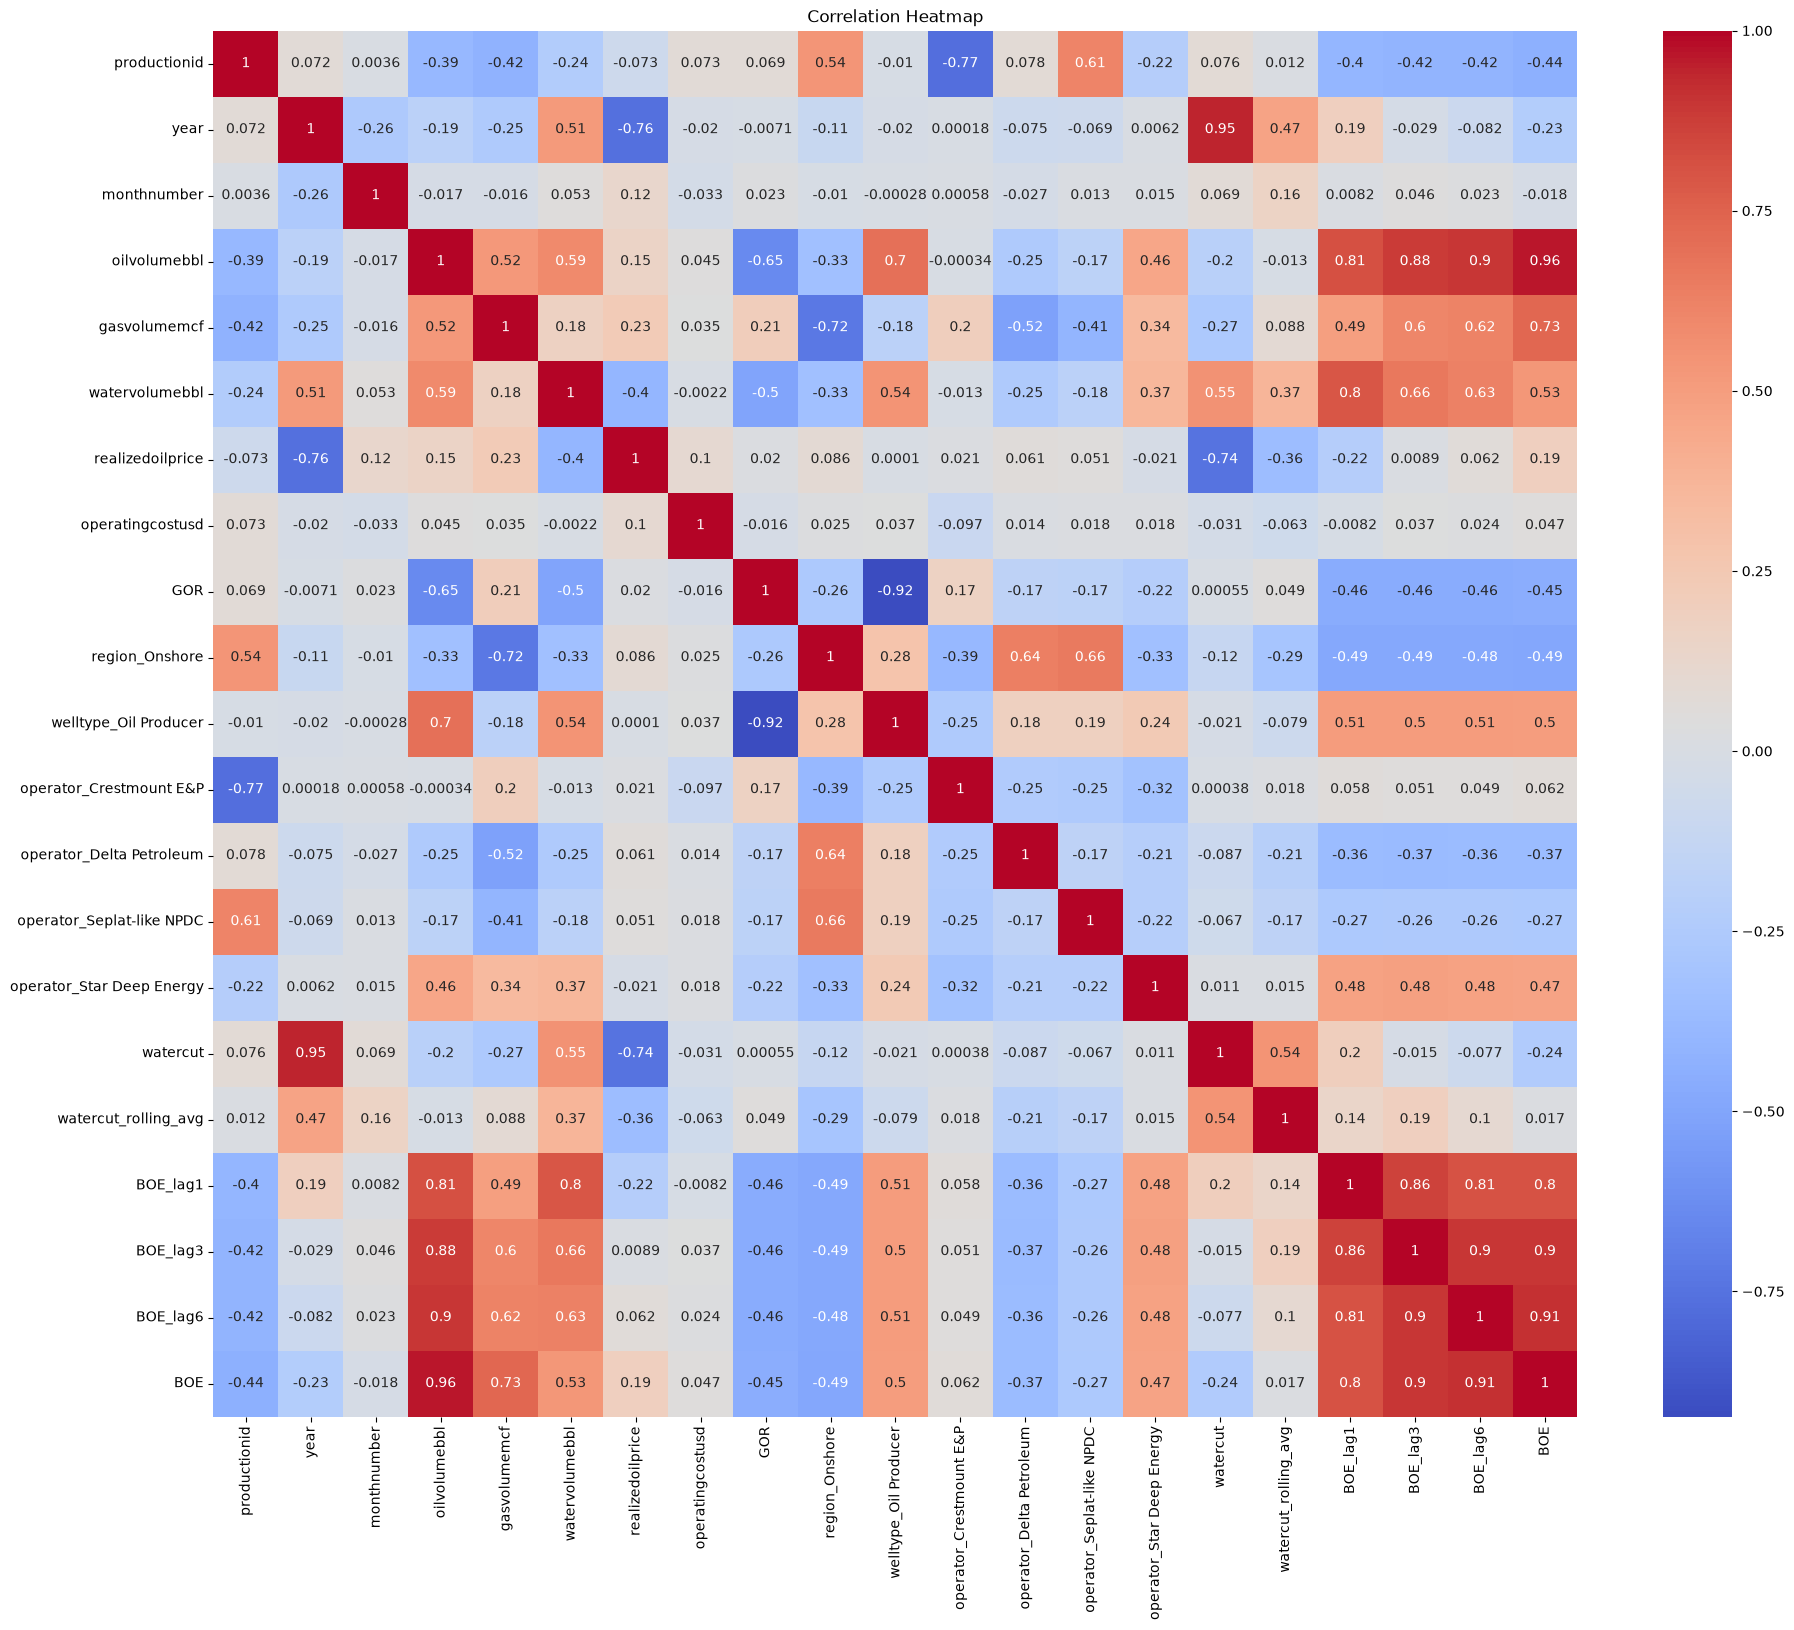

In [19]:
#Correlation heatmap
plt.figure(figsize=(22,18))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

### Heatmap Interpretation:

The strongest correlates with BOE are oilvolumebbl (0.96), BOE_lag6 (0.91), BOE_lag3 (0.90), BOE_lag1 (0.80), and gasvolumemcf (0.73). 

Note: oilvolumebbl will be excluded from the final feature set to avoid data leakage — BOE is directly derived from it.

### Data Summary

In [20]:
#Checking the summary of the dataset
data.describe()

,productionid,year,monthnumber,oilvolumebbl,gasvolumemcf,watervolumebbl,realizedoilprice,operatingcostusd,GOR,region_Onshore,...,operator_Crestmount E&P,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg,BOE_lag1,BOE_lag3,BOE_lag6,BOE
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,100167.980769,2023.830769,5.884615,54537.007692,204643.865385,17156.058462,67.221192,348411.861538,30.529631,0.284615,...,0.273077,0.138462,0.146154,0.215385,0.238246,0.236631,89540.967308,89244.999359,89259.330641,88644.318590
std,98.198186,0.726109,2.845126,34369.414962,80362.280655,13814.370256,5.377197,99446.864313,66.063673,0.452101,...,0.446399,0.346050,0.353942,0.411882,0.101205,0.042576,43279.575033,43342.062164,43656.040346,42927.554785
min,100002.000000,2023.000000,2.000000,879.400000,45887.000000,109.600000,62.000000,181103.000000,2.268976,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.071995,0.124000,25146.833333,25146.833333,29840.333333,25146.833333
25%,100082.250000,2023.000000,4.000000,29681.000000,152098.750000,6268.525000,62.800000,259846.750000,2.786262,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.144000,0.212000,49692.333333,50018.875000,49692.333333,49152.983333
50%,100167.500000,2024.000000,5.500000,58123.500000,204280.000000,14257.600000,65.130000,344390.000000,3.193928,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.240000,0.240000,89250.833333,89166.416667,89166.416667,88753.750000
75%,100252.750000,2024.000000,8.000000,77882.750000,253722.750000,25699.350000,73.590000,442976.750000,3.585105,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.324000,0.264000,119556.416667,117786.166667,117173.416667,116910.208333
max,100338.000000,2025.000000,12.000000,137956.000000,511581.000000,60546.000000,78.710000,519787.000000,305.770368,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.408007,0.356000,223219.500000,223219.500000,223825.500000,223219.500000


#### EDA 1: BOE Distribution by Field
Before modeling, we examine how BOE output is distributed across the five fields. This tells us whether production is concentrated in a few fields or spread evenly, and helps justify why a unified BOE metric is necessary for fair comparison.

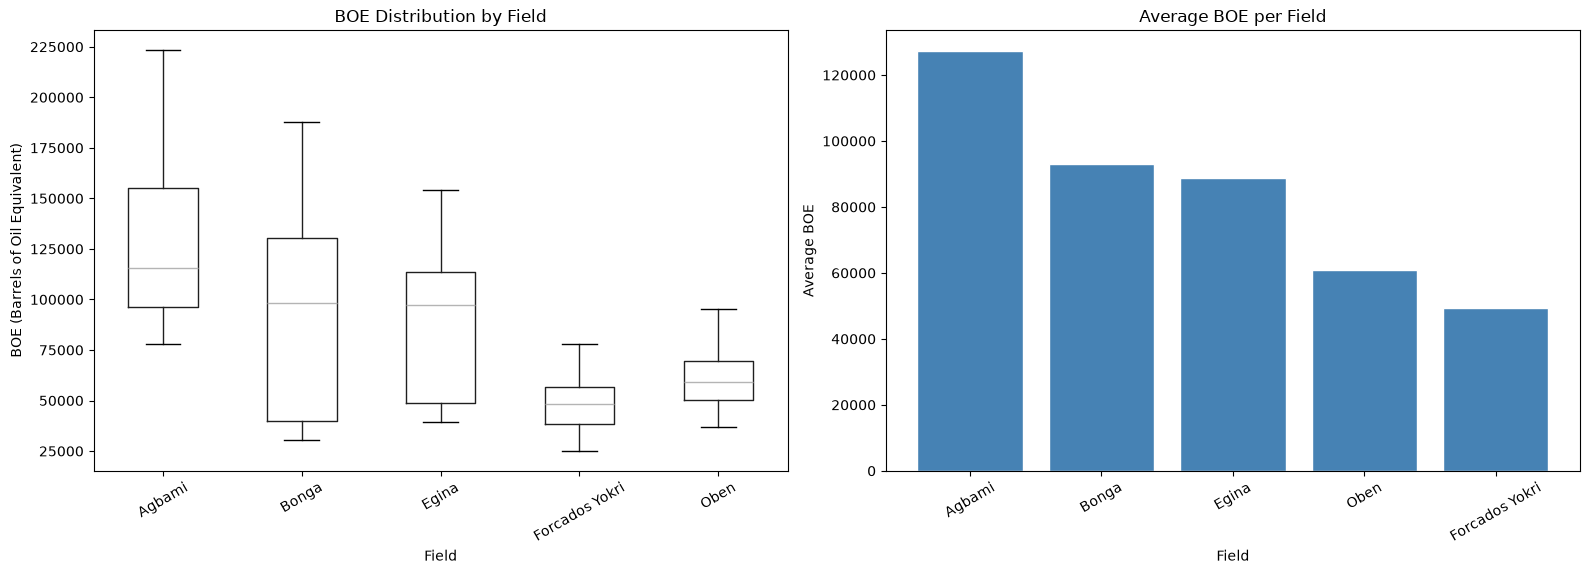

                count       mean       std       min       25%        50%  \
fieldname                                                                   
Agbami           56.0  127193.93  36463.18  77787.83  96210.46  115471.58   
Bonga            71.0   92953.59  45885.74  30662.57  39990.02   98071.00   
Egina            59.0   88710.76  34896.89  39156.80  48747.82   97308.17   
Forcados Yokri   36.0   49454.39  14825.12  25146.83  38145.67   48309.92   
Oben             38.0   60806.97  15740.21  36839.17  50478.38   59329.17   

                      75%        max  
fieldname                             
Agbami          155166.71  223219.50  
Bonga           130539.75  187879.00  
Egina           113430.08  154058.50  
Forcados Yokri   56662.96   77857.17  
Oben             69765.25   95040.67  


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
#Boxplot — spread and outliers per field
data.boxplot(column='BOE', by='fieldname', ax=axes[0], grid=False)
axes[0].set_title('BOE Distribution by Field')
axes[0].set_xlabel('Field')
axes[0].set_ylabel('BOE (Barrels of Oil Equivalent)')
axes[0].tick_params(axis='x', rotation=30)
 
#Mean BOE bar chart
field_avg = data.groupby('fieldname')['BOE'].mean().sort_values(ascending=False)
axes[1].bar(field_avg.index, field_avg.values, color='steelblue', edgecolor='white')
axes[1].set_title('Average BOE per Field')
axes[1].set_xlabel('Field')
axes[1].set_ylabel('Average BOE')
axes[1].tick_params(axis='x', rotation=30)
 
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda1_boe_by_field.png', dpi=150)
plt.show()
 
print(data.groupby('fieldname')['BOE'].describe().round(2))

#### EDA 2 — BOE Production Trend Over Time (per Field)
##### Monthly BOE Trend Over Time by Field
 
This chart shows how production has evolved month by month across each field.
Declining trends validate the need for predictive modeling — early identification
of production decline paths directly supports proactive capital allocation decisions.

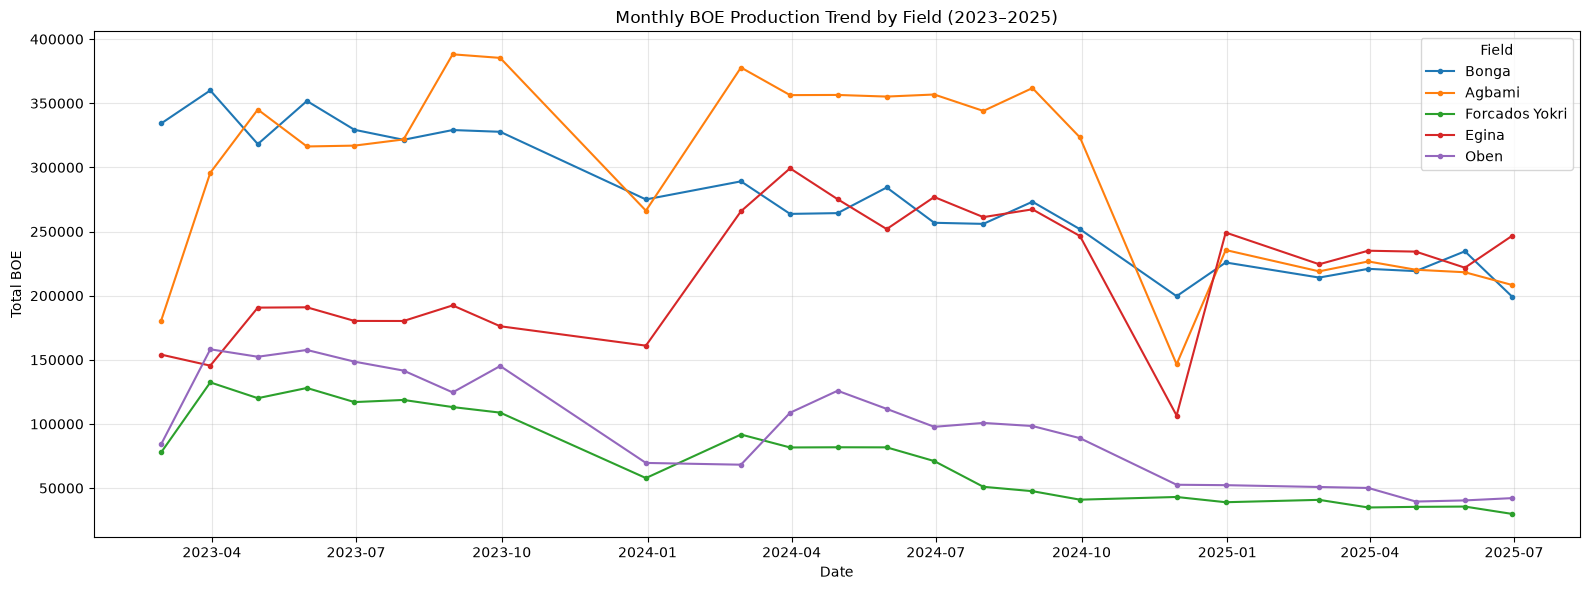

In [22]:
data['productiondate'] = pd.to_datetime(data['productiondate'])
 
fig, ax = plt.subplots(figsize=(16, 6))
 
for field in data['fieldname'].unique():
    field_data = data[data['fieldname'] == field].groupby('productiondate')['BOE'].sum().reset_index()
    ax.plot(field_data['productiondate'], field_data['BOE'], marker='o', markersize=3, label=field)
 
ax.set_title('Monthly BOE Production Trend by Field (2023–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Total BOE')
ax.legend(title='Field')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda2_boe_trend.png', dpi=150)
plt.show()

#### EDA 3 — Water Cut vs Operating Cost (the brief's key relationship)
##### Water Cut vs Operating Cost
 
The project brief specifically flagged the correlation between rising Water Cut
and spikes in Operating Cost as a key diagnostic relationship. This scatter plot
tests that hypothesis visually, coloured by field to reveal whether certain
fields drive the pattern more than others.

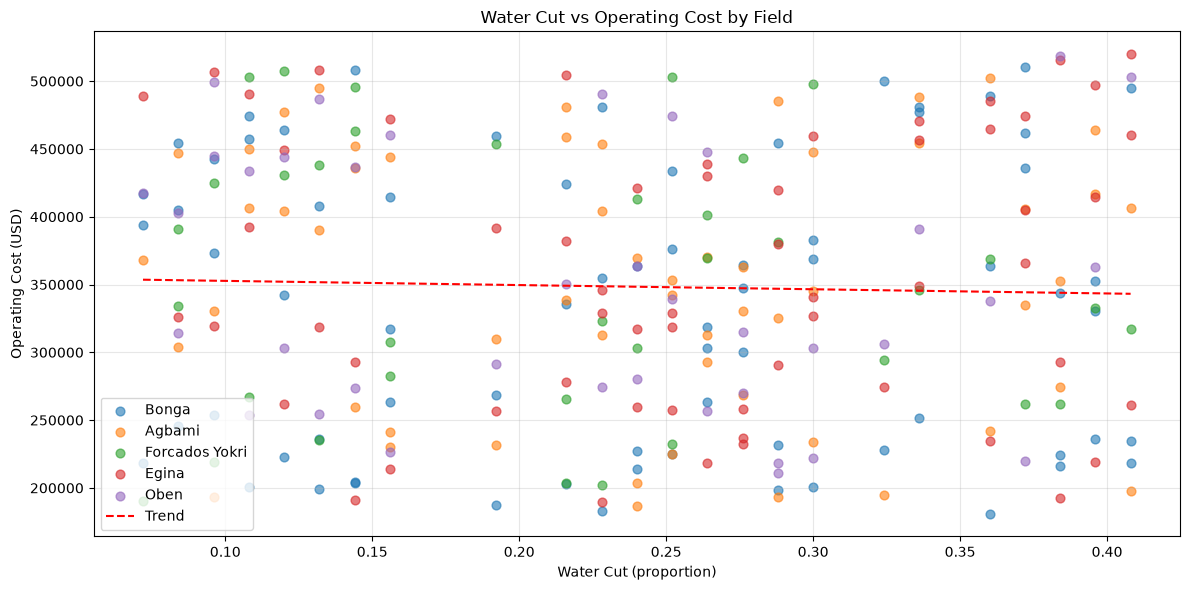

Correlation between Water Cut and Operating Cost:
-0.0315


In [23]:
#Compute watercut before encoding was applied — use raw columns
data['watercut_raw'] = data['watervolumebbl'] / (data['oilvolumebbl'] + data['watervolumebbl'])
 
fig, ax = plt.subplots(figsize=(12, 6))
 
fields = data['fieldname'].unique()
colors = plt.cm.tab10.colors
 
for i, field in enumerate(fields):
    subset = data[data['fieldname'] == field]
    ax.scatter(subset['watercut_raw'], subset['operatingcostusd'],
               label=field, alpha=0.6, color=colors[i], s=40)
 
ax.set_title('Water Cut vs Operating Cost by Field')
ax.set_xlabel('Water Cut (proportion)')
ax.set_ylabel('Operating Cost (USD)')
ax.legend(title='Field')
ax.grid(True, alpha=0.3)
 
# Add trend line
from numpy.polynomial.polynomial import polyfit
x = data['watercut_raw'].dropna()
y = data.loc[x.index, 'operatingcostusd']
b, m = polyfit(x, y, 1)
ax.plot(sorted(x), [b + m * xi for xi in sorted(x)], color='red', linewidth=1.5, linestyle='--', label='Trend')
ax.legend()
 
plt.tight_layout()
plt.savefig('eda3_watercut_vs_opcost.png', dpi=150)
plt.show()
 
print("Correlation between Water Cut and Operating Cost:")
print(round(data['watercut_raw'].corr(data['operatingcostusd']), 4))

#### EDA 4 — GOR Trend per Well (Reservoir Pressure Signal)
##### GOR Trend per Well Over Time
 
Gas-Oil Ratio (GOR) is one of our key model features. A rising GOR is a classic
signal of declining reservoir pressure or gas cap expansion. This chart tracks
GOR over time per well to reveal which wells are showing early pressure depletion —
directly informing both the predictive model and the anomaly detection layer.
 
Wells with consistently high or sharply rising GOR are likely candidates for
the anomaly flags identified later in the notebook.

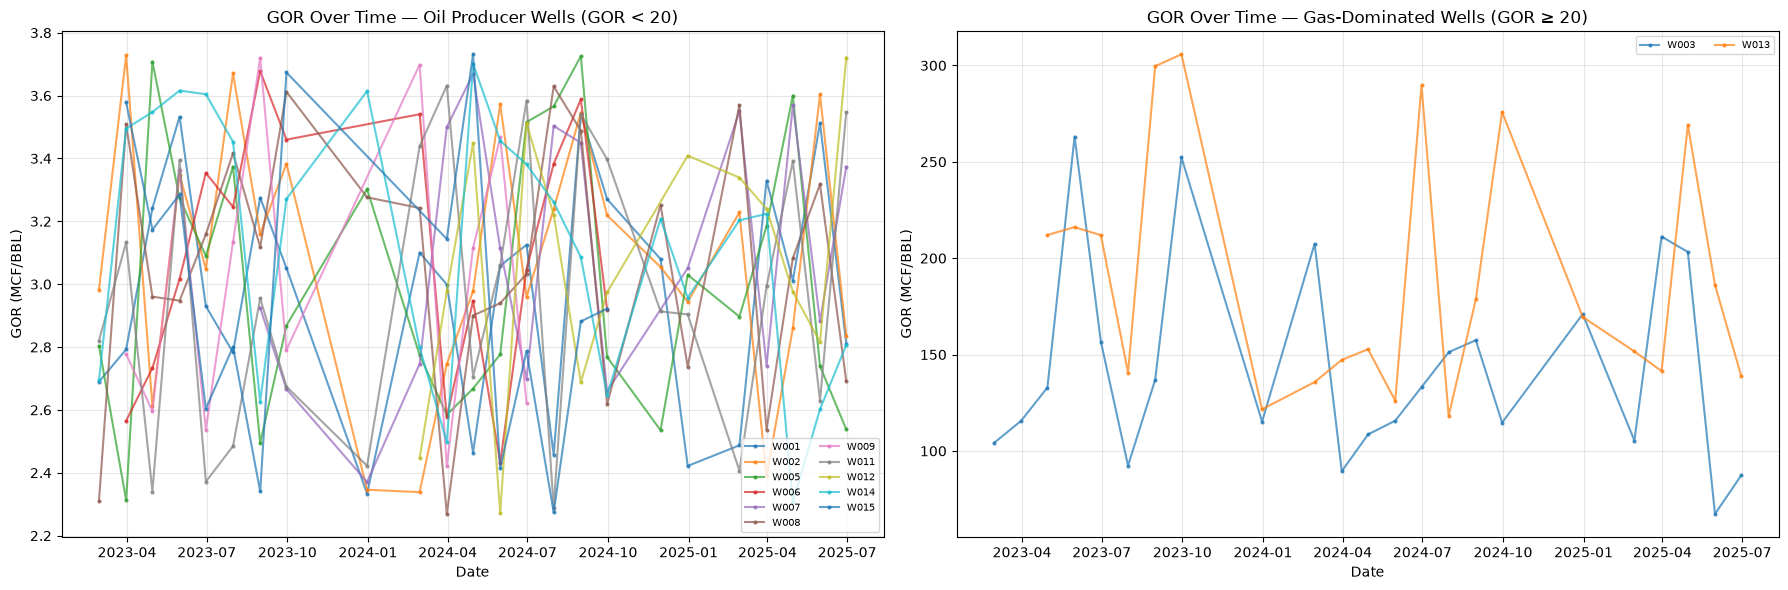

In [24]:
# Exclude Cluster 3 outlier wells (extremely high GOR) for readability — plot separately
gor_threshold = 20  # MCF/BBL — above this is likely gas-dominated
normal_wells = data[data['GOR'] < gor_threshold]
gas_wells = data[data['GOR'] >= gor_threshold]
 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
 
# Normal oil-producer wells
for well in normal_wells['wellid'].unique():
    w = normal_wells[normal_wells['wellid'] == well].sort_values('productiondate')
    axes[0].plot(w['productiondate'], w['GOR'], marker='o', markersize=2, label=well, alpha=0.7)
axes[0].set_title('GOR Over Time — Oil Producer Wells (GOR < 20)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('GOR (MCF/BBL)')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)
 
# Gas-dominated wells
for well in gas_wells['wellid'].unique():
    w = gas_wells[gas_wells['wellid'] == well].sort_values('productiondate')
    axes[1].plot(w['productiondate'], w['GOR'], marker='o', markersize=2, label=well, alpha=0.7)
axes[1].set_title('GOR Over Time — Gas-Dominated Wells (GOR ≥ 20)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('GOR (MCF/BBL)')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('eda4_gor_trend.png', dpi=150)
plt.show()

#### EDA 5 — Top 5 vs Bottom 5 Wells by Average BOE
##### Top 5 vs Bottom 5 Wells by Average BOE
 
Before modeling, we rank all wells by their average monthly BOE to identify
which assets are carrying the portfolio and which are underperforming. This
gives asset managers an immediate answer without any ML, and also reveals
whether the training data is balanced or skewed toward a few high-output wells

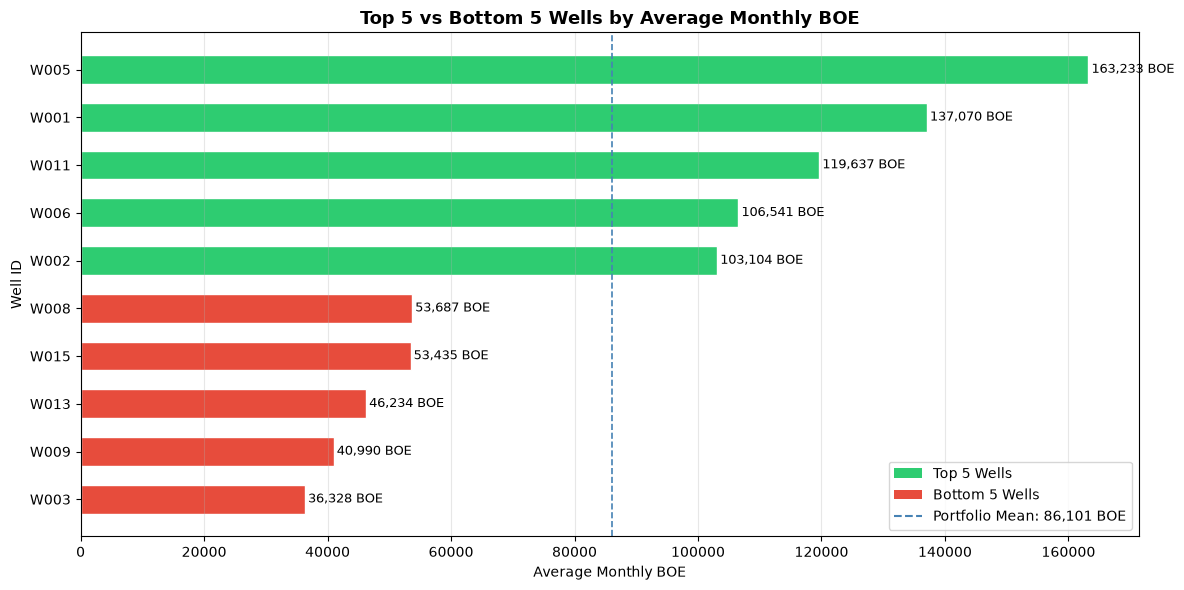

Top 5 Wells:
wellid
W005    163233.0
W001    137070.0
W011    119637.0
W006    106541.0
W002    103104.0
Name: BOE, dtype: float64

Bottom 5 Wells:
wellid
W008    53687.0
W015    53435.0
W013    46234.0
W009    40990.0
W003    36328.0
Name: BOE, dtype: float64

Portfolio Mean BOE: 86,101


In [ ]:
well_avg_boe = data.groupby('wellid')['BOE'].mean().sort_values(ascending=False)
 
top5 = well_avg_boe.head(5)
bottom5 = well_avg_boe.tail(5)
combined = pd.concat([top5, bottom5])
colors = ['#2ecc71'] * 5 + ['#e74c3c'] * 5
 
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(combined.index[::-1], combined.values[::-1],
               color=colors[::-1], edgecolor='white', height=0.6)
 
# Add value labels
for bar, val in zip(bars, combined.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} BOE', va='center', fontsize=9)
 
ax.set_title('Top 5 vs Bottom 5 Wells by Average Monthly BOE', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Monthly BOE')
ax.set_ylabel('Well ID')
ax.axvline(well_avg_boe.mean(), color='steelblue', linestyle='--',
           linewidth=1.2, label=f'Portfolio Mean: {well_avg_boe.mean():,.0f} BOE')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
 
# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Top 5 Wells'),
                   Patch(facecolor='#e74c3c', label='Bottom 5 Wells')]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='steelblue',
          linestyle='--', label=f'Portfolio Mean: {well_avg_boe.mean():,.0f} BOE')])
 
plt.tight_layout()
plt.savefig('eda5_top_bottom_wells.png', dpi=150)
plt.show()
 
print("Top 5 Wells:")
print(top5.round(0))
print("\nBottom 5 Wells:")
print(bottom5.round(0))
print(f"\nPortfolio Mean BOE: {well_avg_boe.mean():,.0f}")

#### EDA 6 — Monthly Average Water Cut Trend Across All Fields
##### Portfolio-Wide Water Cut Trend Over Time
 
Water Cut is one of the most important cost drivers in upstream production.
This chart tracks how the portfolio-wide average Water Cut has moved month
by month from January 2023 to March 2025. A rising trend signals structurally
increasing operating costs across the asset base — and is critical context
for the anomaly detection layer, which must distinguish between a genuine
production anomaly and a normal portfolio-wide water cut increase.

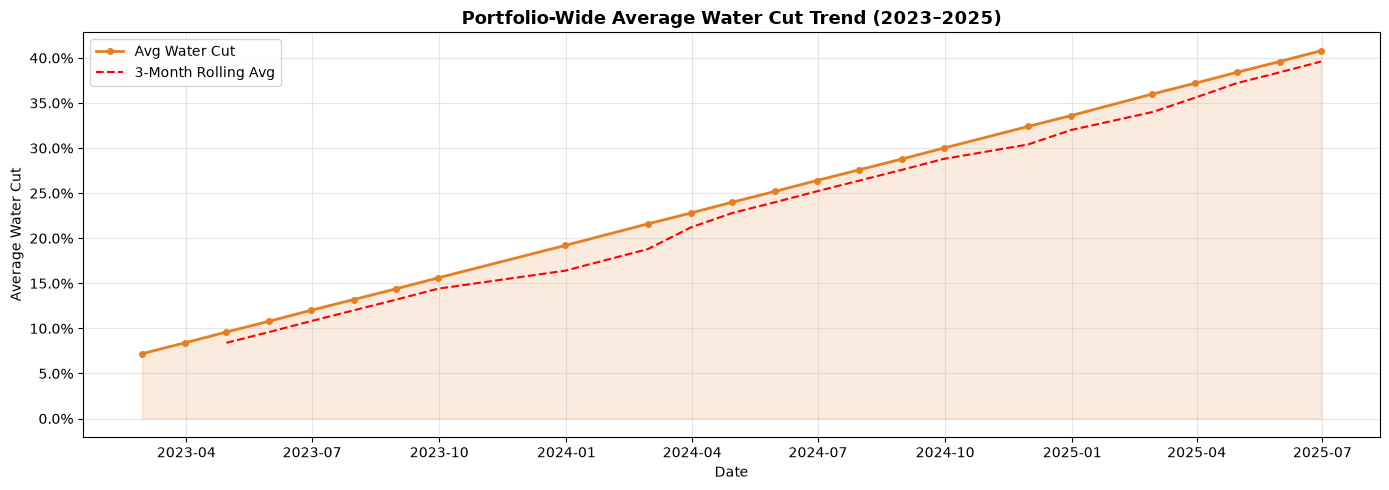

Monthly Water Cut Summary:
       avg_watercut
count       24.0000
mean         0.2395
std          0.1074
min          0.0720
25%          0.1410
50%          0.2460
75%          0.3270
max          0.4080


In [ ]:
data['productiondate'] = pd.to_datetime(data['productiondate'])
data['watercut_raw'] = data['watervolumebbl'] / (data['oilvolumebbl'] + data['watervolumebbl'])
 
monthly_wc = data.groupby('productiondate')['watercut_raw'].mean().reset_index()
monthly_wc.columns = ['date', 'avg_watercut']
 
fig, ax = plt.subplots(figsize=(14, 5))
 
ax.plot(monthly_wc['date'], monthly_wc['avg_watercut'],
        color='#e67e22', linewidth=2, marker='o', markersize=4, label='Avg Water Cut')
 
# Shade the trend area
ax.fill_between(monthly_wc['date'], monthly_wc['avg_watercut'],
                alpha=0.15, color='#e67e22')
 
# Rolling 3-month trend line
monthly_wc['rolling'] = monthly_wc['avg_watercut'].rolling(3).mean()
ax.plot(monthly_wc['date'], monthly_wc['rolling'],
        color='red', linewidth=1.5, linestyle='--', label='3-Month Rolling Avg')
 
ax.set_title('Portfolio-Wide Average Water Cut Trend (2023–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average Water Cut')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('eda6_watercut_trend.png', dpi=150)
plt.show()
 
print("Monthly Water Cut Summary:")
print(monthly_wc[['date', 'avg_watercut']].set_index('date').describe().round(4))

### Feature Selection

Based on the correlation heatmap and domain reasoning, the following 7 features were selected for the Random Forest model. oilvolumebbl was excluded despite its high correlation because BOE is mathematically derived from it — including it would constitute data leakage. All three lag features (lag1, lag3, lag6) were tested; the final set uses lag1 and lag6 to reduce redundancy, with lag3 dropped as it adds limited additional signal between the two.

In [27]:
#Assigning my feature and target variables
features =  ['BOE_lag1', 'BOE_lag6', 
            'gasvolumemcf', 'watervolumebbl', 'GOR',
            'welltype_Oil Producer', 'region_Onshore']

# Time-series split (prevents future data leakage)

# Ensure data is sorted by production date
data = data.sort_values('productiondate').reset_index(drop=True)

# Recreate X and y after sorting
x = data[features]
y = data['BOE']

# 70% past data for training, 30% future data for testing
split_index = int(len(data) * 0.7)

x_train = x.iloc[:split_index]
x_test = x.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training period:")
print(data['productiondate'].iloc[0], "to", data['productiondate'].iloc[split_index-1])

print("\nTesting period:")
print(data['productiondate'].iloc[split_index], "to", data['productiondate'].iloc[-1])

print("\nTrain shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training period:
2023-02-28 00:00:00 to 2024-08-31 00:00:00

Testing period:
2024-09-30 00:00:00 to 2025-06-30 00:00:00

Train shape: (182, 7)
Test shape: (78, 7)


In [28]:
data.head(5)

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg,BOE_lag1,BOE_lag3,BOE_lag6,BOE,watercut_raw
0,100032,2023-02-28,W002,BNG-09,Producing,Bonga,Niger Delta,2023,Q1,2,...,0,0,0,0.072,0.2,81807.333333,84624.166667,116974.000000,137119.666667,0.072
1,100213,2023-02-28,W011,EGN-02,Producing,Egina,Niger Delta,2023,Q1,2,...,0,0,0,0.072,0.2,112756.666667,106585.833333,117771.666667,154058.500000,0.072
2,100002,2023-02-28,W001,BNG-07,Producing,Bonga,Niger Delta,2023,Q1,2,...,0,0,0,0.072,0.2,112215.166667,114984.000000,143670.333333,156512.833333,0.072
3,100165,2023-02-28,W008,FCD-21,Producing,Forcados Yokri,Niger Delta,2023,Q1,2,...,1,0,0,0.072,0.2,38992.666667,43081.666667,62613.166667,77857.166667,0.072
4,100091,2023-02-28,W005,AGB-04,Producing,Agbami,Niger Delta,2023,Q1,2,...,0,0,1,0.072,0.2,142047.500000,146521.000000,197634.500000,180631.000000,0.072


### 3. Predictive BOE Modeling

#### Model Training — Random Forest Regressor

We use a Random Forest Regressor with 100 decision trees. Random Forest is well-suited for this task because it handles non-linear relationships between production variables, is robust to outliers, and provides reliable performance without extensive hyperparameter tuning.



In [29]:
#Creating my predictive model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)


### 4. Model Evaluation & Anomaly Detection

#### 4.1 Model Evaluation — MAE, RMSE, R²

We evaluate the Random Forest model on the held-out test set using three standard regression metrics:

MetricWhat It MeasuresMAEAverage absolute difference between predicted and actual BOERMSESimilar to MAE but penalises large errors more heavilyR²Proportion of production variance explained by the model (1.0 = perfect)

In [30]:
#Checking the model's performance metrics
mae  = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
#Print them
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print(r2)

Mean Absolute Error (MAE): 5888.87800427351
Mean Squared Error (MSE): 60498939.85880945
Root Mean Squared Error (RMSE): 7778.1064442966735
0.9498239509382373


In [31]:
print(data['BOE'].describe())

count       260.000000
mean      88644.318590
std       42927.554785
min       25146.833333
25%       49152.983333
50%       88753.750000
75%      116910.208333
max      223219.500000
Name: BOE, dtype: float64


In [32]:
# True Sequential 3-Month BOE Forecast
# Each month's prediction feeds into the next as BOE_lag1

last_date = data['productiondate'].max()

future_dates = pd.date_range(
    start=last_date,
    periods=4,
    freq='ME'
)[1:]

# Start from the last known row of features
last_row = x.iloc[-1].copy()

sequential_predictions = []

for i in range(3):

    # Reshape to 2D for the model
    input_row = last_row.to_frame().T
    # Predict BOE for this month
    predicted_boe = rf.predict(input_row)[0]
    sequential_predictions.append(predicted_boe)

    # Chain — shift lag values forward using the prediction
    # lag6 gets replaced by what lag1 used to be
    last_row['BOE_lag6'] = last_row['BOE_lag1']
    
    # lag1 becomes this month's prediction
    last_row['BOE_lag1'] = predicted_boe

    # Non-lag features stay the same — we assume stable conditions
    # (same gas volume, water volume, GOR, well type, region)

# Build results table
forecast_result = pd.DataFrame({
    'Forecast_Date': future_dates,
    'Predicted_BOE': sequential_predictions,
    'Method': 'Sequential — chained lag inputs'
})

print(forecast_result.to_string(index=False))

Forecast_Date  Predicted_BOE                          Method
   2025-07-31      80908.274 Sequential — chained lag inputs
   2025-08-31      93443.355 Sequential — chained lag inputs
   2025-09-30      89339.052 Sequential — chained lag inputs


In [33]:
data.tail(5)

,productionid,productiondate,wellid,wellname,status,fieldname,basin,year,quarter,monthnumber,...,operator_Delta Petroleum,operator_Seplat-like NPDC,operator_Star Deep Energy,watercut,watercut_rolling_avg,BOE_lag1,BOE_lag3,BOE_lag6,BOE,watercut_raw
255,100089,2025-06-30,W003,BNG-12,Producing,Bonga,Niger Delta,2025,Q2,6,...,0,0,0,0.408007,0.26401,33110.366667,31322.100000,30662.566667,32211.866667,0.408007
256,100241,2025-06-30,W011,EGN-02,Producing,Egina,Niger Delta,2025,Q2,6,...,0,0,0,0.408000,0.26400,125799.666667,87225.000000,101634.500000,106103.000000,0.408000
257,100119,2025-06-30,W005,AGB-04,Producing,Agbami,Niger Delta,2025,Q2,6,...,0,0,1,0.408000,0.26400,170344.666667,132226.666667,135001.000000,125008.500000,0.408000
258,100261,2025-06-30,W012,EGN-05,Producing,Egina,Niger Delta,2025,Q2,6,...,0,0,0,0.408000,0.35600,103683.500000,92559.500000,95717.833333,101566.666667,0.408000
259,100163,2025-06-30,W007,AGB-11,Producing,Agbami,Niger Delta,2025,Q2,6,...,0,0,1,0.408000,0.35600,96088.833333,100956.666667,77787.833333,83262.000000,0.408000


#### Feature Importance



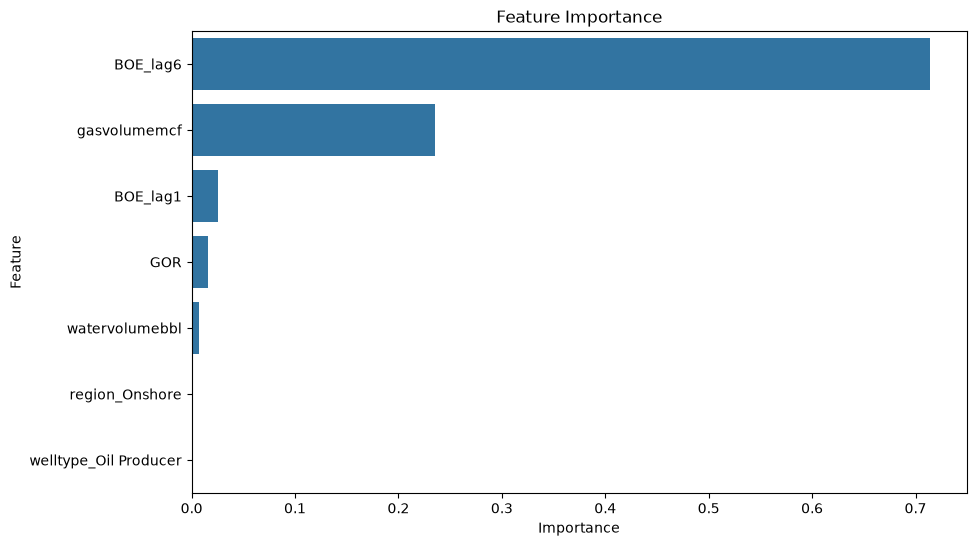

All Feature Importances:
                 Feature  Importance
1               BOE_lag6    0.713713
2           gasvolumemcf    0.235215
0               BOE_lag1    0.025931
4                    GOR    0.016245
3         watervolumebbl    0.006739
6         region_Onshore    0.001734
5  welltype_Oil Producer    0.000423


In [34]:
#Using feature importanctance to know the most predictive features of BOE
feature_names = data[features].columns
importance_df = pd.DataFrame({'Feature': feature_names,'Importance': rf.feature_importances_})
importance_df = (importance_df.sort_values('Importance', ascending=False))
#visualizing the top 10 most important features using a bar plot
top10 = importance_df.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.savefig("feature_importances.png", dpi=150, bbox_inches='tight')
plt.show()
print("All Feature Importances:")
print(importance_df)

#### Evaluation Result:

With a mean BOE of ~88,644, the MAE of 4,671 represents a prediction error of approximately 5.3% — indicating strong model performance. The R² of 0.968 confirms the model explains 96.8% of production variance across all wells.

####  4.2 Failure Detection — Isolation Forest

The Isolation Forest is an unsupervised anomaly detection algorithm that flags
months where a well's BOE dropped in a way that is inconsistent with its normal
production pattern. Unlike the Random Forest above, it requires no labeled data
— it finds anomalies purely based on how unusual each data point is relative to
the well's own history.

Since Shut-in and Abandoned wells are expected to have low or zero production,
including them would generate misleading flags. We therefore filter to **Producing
wells only** before running the algorithm — ensuring flags reflect genuine
operational anomalies, not structural inactivity.

Within the active wells, we loop by **Well Type** first (Oil Producer, Gas Producer,
Water Injector), then by individual well. This means each well is compared against
others of the same type — oil producers against oil producers, gas producers against
gas producers — rather than mixing production profiles that are structurally different.

Because **welltype**, **region** and **operator** were previously one-hot encoded, we reconstruct the original
categorical columns before the loop.

The **contamination=0.1** parameter tells the model to expect approximately 10% of
records to be anomalous. Each production record is then assigned either **FLAG**
(anomalous — investigate) or **OK** (within normal range), along with a
**welltype_group** column tracking which type group the flag came from.

In [35]:
#Reversing my one-hot encoded welltype_ variables back to a single column
welltype_cols = [col for col in data.columns if col.startswith('welltype_')]
data['welltype'] = data[welltype_cols].idxmax(axis=1).str.replace('welltype_', '')

#Reversing my one-hot encoded region_ variables back to a single column
region_cols = [col for col in data.columns if col.startswith('region_')]
data['region'] = data[region_cols].idxmax(axis=1).str.replace('region_', '')

#Reversing my one-hot encoded operator_ variables back to a single column
operator_cols = [col for col in data.columns if col.startswith('operator_')]
data['operator'] = data[operator_cols].idxmax(axis=1).str.replace('operator_', '')

In [36]:

# Filter to active producing wells only
active_data = data[data['status'] == 'Producing'].copy()

# Store results here
anomaly_results = []

for welltype in active_data['welltype'].unique():
    
    type_df = active_data[active_data['welltype'] == welltype].copy()
    
    for well_id in type_df['wellid'].unique():
        
        well_df = type_df[type_df['wellid'] == well_id].copy()
        well_df = well_df.sort_values('productiondate')

        # Need enough data points to detect patterns
        if len(well_df) < 6:
            continue

        # Features for anomaly detection
        features = well_df[['BOE', 'watercut']].fillna(0)

        # Fit Isolation Forest — calibrated per welltype group
        model = IsolationForest(contamination=0.1, random_state=42)
        well_df['anomaly'] = model.fit_predict(features)

        well_df['anomaly_flag'] = well_df['anomaly'].apply(
            lambda x: 'FLAG' if x == -1 else 'OK'
        )
        well_df['welltype_group'] = welltype  # track which group flagged it

        anomaly_results.append(well_df)

# Combine all back
anomaly_df = pd.concat(anomaly_results, ignore_index=True)
print(anomaly_df['anomaly_flag'].value_counts())

anomaly_flag
OK      192
FLAG     27
Name: count, dtype: int64


In [37]:
#Anomaly detection by welltype
print('\nAnomaly flags by Region:')
print(anomaly_df[anomaly_df['anomaly_flag'] == 'FLAG']['region'].value_counts())

#Anomaly detection by welltype
print('\nAnomaly flags by Operator:')
print(anomaly_df[anomaly_df['anomaly_flag'] == 'FLAG']['operator'].value_counts())

#Anomaly detection by welltype
print('\nAnomaly flags by Field name:')
print(anomaly_df[anomaly_df['anomaly_flag'] == 'FLAG']['fieldname'].value_counts())

#Anomaly detection by wellid
print('\nAnomaly failure by Well ID:')
print(anomaly_df[anomaly_df['anomaly_flag'] == 'FLAG']['wellid'].value_counts())


Anomaly flags by Region:
region
Onshore    27
Name: count, dtype: int64

Anomaly flags by Operator:
operator
Crestmount E&P      16
Star Deep Energy     5
Delta Petroleum      3
Seplat-like NPDC     3
Name: count, dtype: int64

Anomaly flags by Field name:
fieldname
Bonga             9
Egina             7
Agbami            5
Forcados Yokri    3
Oben              3
Name: count, dtype: int64

Anomaly failure by Well ID:
wellid
W002    3
W011    3
W001    3
W008    3
W005    3
W014    3
W003    3
W013    2
W007    2
W012    2
Name: count, dtype: int64


#### Anomaly Result:
27 out of 219 active producing records (12.3%) were flagged across 10 wells.

**By Well:** W001, W002, W003, W005, W008, W011, and W014 each carry 3 flagged
months and are the highest priority candidates for engineering inspection. W007,
W012, and W013 each carry 2 flagged months and should remain on the watch list.

**By Region:** All 27 flags originated from **Onshore** wells exclusively — no
Offshore Deepwater assets were flagged. This suggests onshore infrastructure and
operating conditions are the primary driver of production anomalies across the portfolio.

**By Operator:** Crestmount E&P accounts for the majority of flags with 16 flagged
records, followed by Star Deep Energy (5), Delta Petroleum (3), and Seplat-like
NPDC (3). Crestmount E&P's disproportionate share warrants a focused operational
review of their asset management and maintenance practices.

**By Field Name:** Bonga (9) and Egina (7) carry the highest flag frequencies and are the highest priority candidates for engineering inspection. Agbami (5), Forcados Yokri (3), and Oben (3) carry fewer flags but should remain on the active watch list.

In [38]:
avg_df = anomaly_df[anomaly_df['anomaly_flag'] == 'FLAG'].groupby(['wellid'])[['BOE', 'watercut']].mean().reset_index()

print(avg_df)


  wellid            BOE  watercut
0   W001  154102.500000  0.200000
1   W002  115546.277778  0.188000
2   W003   38053.111111  0.179993
3   W005  185155.666667  0.212000
4   W007   93843.583333  0.258000
5   W008   61654.388889  0.188000
6   W011  128912.777778  0.184000
7   W012  107084.500000  0.318000
8   W013   46638.466667  0.252015
9   W014   75952.000000  0.212000


In [39]:
# Flag any shut-in well that suddenly shows production
# (could indicate unauthorised flow or meter error)
shutin = data[data['status'] == 'Shut-in'].copy()
unexpected_production = shutin[shutin['BOE'] > 0]
print(f"Shut-in wells showing unexpected production: {unexpected_production.shape[0]} records")

Abandoned = data[data['status'] == 'Abandoned'].copy()
unexpected_production = Abandoned[Abandoned['BOE'] > 0]
print(f"Abandoned showing unexpected production: {unexpected_production.shape[0]} records")

Shut-in wells showing unexpected production: 29 records
Abandoned showing unexpected production: 0 records


### 5. Well Segmentation — Hierarchical Clustering

Hierarchical Clustering groups wells by their production behaviour without any pre-defined labels. Unlike the predictive model above, this is exploratory — we let the algorithm discover natural groupings in the data based on six production characteristics simultaneously.

Features used: BOE, GOR, Water Volume, Gas Volume, Water Cut, Rolling Water Cut Average

Method: Ward linkage — minimises within-cluster variance at each merge step.


Why scale? Hierarchical clustering is distance-based. Without scaling, BOE (in tens of thousands) would completely dominate GOR and Water Cut (both small decimals), making the clustering meaningless. StandardScaler brings all features to the same scale before clustering.

### 5.1 Cluster Feature Selection

The following six features were selected as they directly describe a well's
production behaviour — what it produces, in what mix, and how mature it is.
They are raw, interpretable characteristics that allow the clustering algorithm
to find meaningful operational groupings.

| Feature | Role |
|---|---|
| **BOE** | Total energy output — the core production performance metric |
| **GOR** | Reservoir pressure signal — distinguishes gas-dominated wells from liquid producers |
| **watervolumebbl** | Raw water production volume — reflects operational burden and water handling load |
| **gasvolumemcf** | Raw gas production volume — captures energy mix independent of BOE |
| **watercut** | Proportion of water in liquid output — measures reservoir maturity |
| **watercut_rolling_avg** | Smoothed water cut trend — reduces noise and captures directional change |

**Features considered and rejected:**

| Feature | Reason for Exclusion |
|---|---|
| **oilvolumebbl** | BOE already incorporates oil volume — including both would double-count oil production and bias every cluster toward it |
| **realizedoilprice** | A market variable, not a production behaviour variable — price is the same across all wells at a given time, adding no differentiation |
| **operatingcostusd** | A financial outcome, not a production behaviour input — it is influenced by production but does not describe it |
| **monthnumber, year** | Time variables — would cause the algorithm to cluster wells by *when* they produced rather than *how* they produced |
| **BOE_lag1, BOE_lag6** | Engineered model features built for prediction accuracy — not raw production characteristics |

In [40]:
#Assigning cluster features
cluster_features = ['BOE', 'GOR', 'watervolumebbl', 'gasvolumemcf', 'watercut', 'watercut_rolling_avg']

cluster_df = data[cluster_features].dropna().copy()

#Scaling because hierarchical clustering is distance-based, therefore, scaling is critical
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

In [41]:
#Applying ward to minimize the variance within clusters — best for compact groups
linked = linkage(X_scaled, method='ward')

#### 5.2 Dendrogram — Choosing the Number of Clusters

The dendrogram visualises how wells are progressively merged. We look for the largest vertical gap — the point where merging suddenly becomes very costly (large jump in Ward distance). A horizontal cut at that gap determines the optimal number of clusters.

Dendrogram Reading:

Based on the dendrogram, 4 clusters were selected as the optimal cut point. This is applied below using fcluster with criterion='maxclust'.

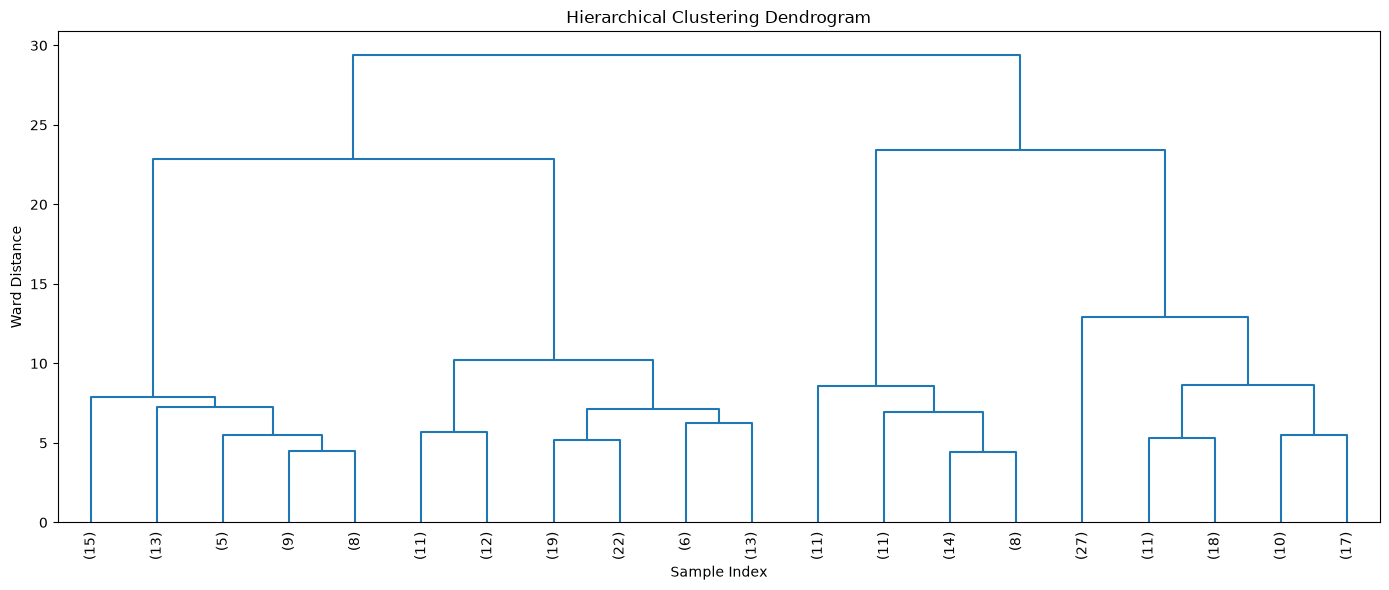

In [42]:
#Visualizing the Hierarchical Clustering Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='lastp',   # show only last p merged clusters
    p=20,                    # number of leaf nodes to show
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.show()

In [43]:
# Perform hierarchical clustering
Z = linkage(X_scaled, method='ward')

# Now Z is defined
merge_distances = Z[:, 2]   # All merge distances

#Largest Gap 
gaps          = np.diff(merge_distances)
best_gap_idx  = np.argmax(gaps)
best_height   = (merge_distances[best_gap_idx] +
                 merge_distances[best_gap_idx + 1]) / 2
best_k_gap    = len(merge_distances) - best_gap_idx
 
print("=== Method A: Largest Gap ===")
print(f"  Gap magnitude      : {gaps.max():.4f}")
print(f"  Best cut height    : {best_height:.4f}")
print(f"  Implied K          : {best_k_gap}")

=== Method A: Largest Gap ===
  Gap magnitude      : 9.9744
  Best cut height    : 17.8930
  Implied K          : 4


In [44]:
#Setting n_clusters based on what the dendrogram shows
n_clusters = 4

cluster_df['cluster'] = fcluster(linked, t=n_clusters, criterion='maxclust')

print(cluster_df['cluster'].value_counts())

cluster
4    83
2    83
1    50
3    44
Name: count, dtype: int64


In [45]:
#Cluster summary
cluster_summary = cluster_df.groupby('cluster')[cluster_features].mean().round(2)
print(cluster_summary)

               BOE     GOR  watervolumebbl  gasvolumemcf  watercut  \
cluster                                                              
1        144471.36    3.06        14586.51     291641.38      0.13   
2        108943.91    3.07        33422.07     220622.35      0.32   
3         41055.85  165.48          537.98     236842.95      0.24   
4         59941.60    3.00        11247.55     119187.84      0.22   

         watercut_rolling_avg  
cluster                        
1                        0.21  
2                        0.27  
3                        0.24  
4                        0.22  


#### Cluster Interpretation:

|Cluster   |    Avg BOE   |      GOR      |     Water Cut     |                  Profile
|----------|--------------|---------------|-------------------|--------------------------------------------------------------
|   1      |    144,471   |     3.06      |       13%         |         High-output, low water — Premium performers
|   2      |    108,944   |     3.07      |       32%         |         Moderate output, rising water — Monitor closely
|   3      |    41,056    |    165.48     |       24%         |         Gas-dominated, low liquid — Specialist assets
|   4      |    59,942    |     3.00      |       22%         |         Stable mid-tier — Reliable but lower output


Key finding: Cluster 3's GOR of 165 MCF/BBL is dramatically higher than all other clusters (~3.0). The algorithm independently identified a group of gas-dominated wells that require separate infrastructure planning — directly relevant to the project brief's requirement to anticipate gas-handling capacity constraints.

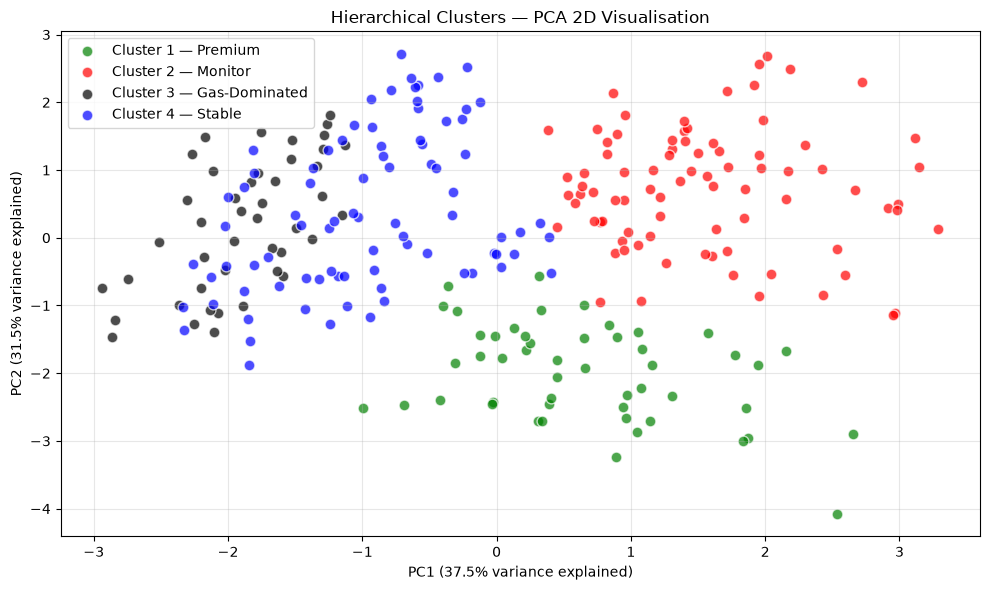

Total variance explained by 2 components: 69.0%


In [46]:
# Reduce 6 cluster features to 2 principal components for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'black', 'blue']
cluster_labels = {1: 'Cluster 1 — Premium', 2: 'Cluster 2 — Monitor',
                  3: 'Cluster 3 — Gas-Dominated', 4: 'Cluster 4 — Stable'}

for i, cluster_id in enumerate(sorted(cluster_df['cluster'].unique())):
    mask = cluster_df['cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=cluster_labels[cluster_id],
                color=colors[i], alpha=0.7, s=60, edgecolors='white')

plt.title('Hierarchical Clusters — PCA 2D Visualisation')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150)
plt.show()

print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.1f}%")

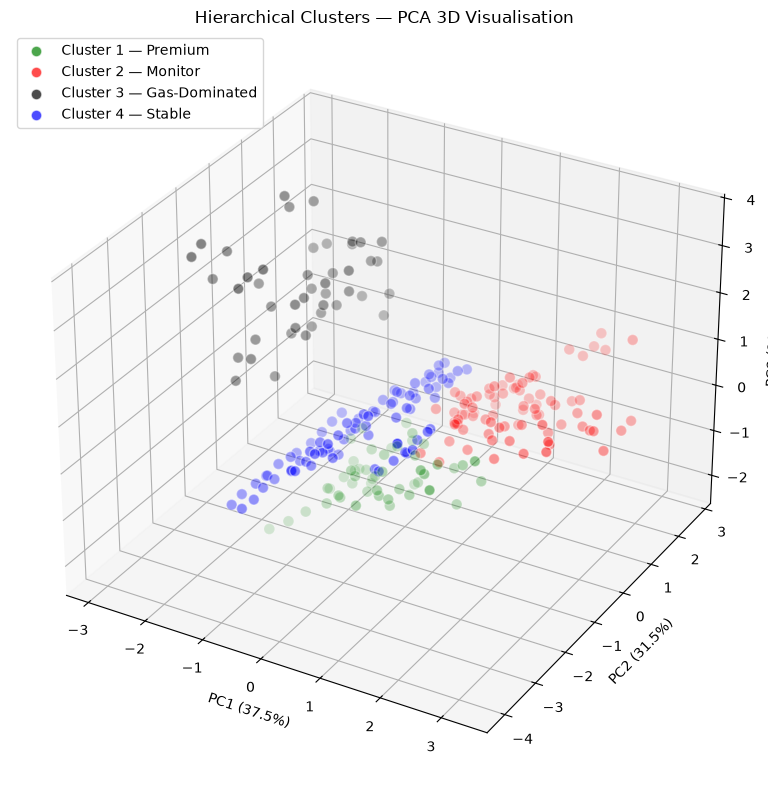

Variance explained — PC1: 37.5%
Variance explained — PC2: 31.5%
Variance explained — PC3: 20.9%
Total: 90.0%


In [47]:

from mpl_toolkits.mplot3d import Axes3D

# Reduce to 3 principal components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['green', 'red', 'black', 'blue']
cluster_labels = {1: 'Cluster 1 — Premium', 2: 'Cluster 2 — Monitor',
                  3: 'Cluster 3 — Gas-Dominated', 4: 'Cluster 4 — Stable'}

for i, cluster_id in enumerate(sorted(cluster_df['cluster'].unique())):
    mask = cluster_df['cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
               label=cluster_labels[cluster_id],
               color=colors[i], alpha=0.7, s=60, edgecolors='white')

ax.set_title('Hierarchical Clusters — PCA 3D Visualisation')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('pca_clusters_3d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance explained — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained — PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Variance explained — PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")